# Double-blind evaluation — Benchmark Owner

| Actor | Email | Role |
|-------|-------|------|
| **Enclave** | `ENCLAVE_EMAIL` | Tinfoil Container that runs the evaluation |
| **Benchmark owner** | `BENCHMARK_OWNER_EMAIL` | Owns the private prompt set |
| **Model owner** | `MODEL_OWNER_EMAIL` | Owns the private LoRA adapter |

**The setting.** A benchmark owner wants to know how a model behaves on prompts it has never
seen. A model owner is willing to be measured but will not hand over the weights. Neither will show
the other what they hold, and neither trusts the machine in the middle.

Both connect to an [enclave](https://github.com/OpenMined/PySyft/tree/dev/packages/syft-enclave) — a
sealed environment whose contents nobody, including whoever runs the hardware, can read. Each
uploads their half. Nothing runs until **both** owners approve the exact code, and the enclave
proves what it is before either of them uploads anything.

This is the flow from [tinfoilsh/double-blind-eval](https://github.com/tinfoilsh/double-blind-eval),
carried out entirely over PySyft. The enclave is a [Tinfoil
Container](https://docs.tinfoil.sh/containers/overview), and the attestation is checked against the
measurement published for a signed release of its config.

We hold the prompts, and we submit the job. The model owner has to approve it before it runs, and
the results come back only to us.

## Setup

In [ ]:
!uv pip install -Uq "syft-enclave[tinfoil] @ git+https://github.com/OpenMined/PySyft.git@dev#subdirectory=packages/syft-enclave"

In [ ]:
import csv
import json
import random
import tempfile
from pathlib import Path

from syft_enclaves import login_do
from syft_enclaves.attestation.tinfoil import TinfoilAppraisalPolicy
from syft_enclaves.receipt import RECEIPT_FILE_NAME, upload_to_rekor, verify_receipt

In [ ]:
ENCLAVE_EMAIL         = "enclave@openmined.org"
BENCHMARK_OWNER_EMAIL = "benchmark_owner@openmined.org"
MODEL_OWNER_EMAIL     = "model_owner@openmined.org"

# What the enclave is checked against. TINFOIL_TAG and IMAGE_DIGEST come from
# whoever deployed it: `just tinfoil-release` prints the digest, and the tag is
# the config release it was deployed from.
TINFOIL_REPO = "OpenMined/syft-enclave-tinfoil"
TINFOIL_TAG  = "v0.1.14"
IMAGE_DIGEST = "sha256:d0bd57f22af80b9dcd0dc151fb68d89cca65b65fcbbd1d2e4586cdfa9d7daebc"

print(f"  Enclave: {ENCLAVE_EMAIL}")
print(f"  Benchmark owner: {BENCHMARK_OWNER_EMAIL}  |  Model owner: {MODEL_OWNER_EMAIL}")
print(f"  Verifying against {TINFOIL_REPO} {TINFOIL_TAG}")

## Step 0 — Log in as Benchmark Owner

Colab authenticates us to Google Drive, which is how every party in this demo reaches every other
one. Nothing here talks to the enclave yet.

In [ ]:
CRYPTO_KEYS_PATH = None
# NOTE: Re-storing Private Key from local_file, if you have it, uncomment the following line and upload the file.
# from google.colab import files; files.upload()
# CRYPTO_KEYS_PATH = "crypto_keys.json"

benchmark_owner = login_do(encryption=True, crypto_keys_path=CRYPTO_KEYS_PATH)
print(f"  Benchmark owner : {benchmark_owner.email}")

In [ ]:
# # Optionally, to start from a clean SyftBox
# benchmark_owner.delete_syftbox()
# benchmark_owner._rds.peer_manager.write_own_version()

## Step 1 — Connect to the enclave and to the model owner

We ask the enclave to peer with us, which is what lets us send it data and jobs. We also peer with
the model owner directly, so we can read their public model card before deciding to run against
their model.

In [ ]:
benchmark_owner.add_peer(ENCLAVE_EMAIL)
benchmark_owner.add_peer(MODEL_OWNER_EMAIL)
print("  Peer requests sent to the enclave and the model owner")

### Step 1.1 — Wait until both accept

The enclave accepts automatically; the model owner approves us from their notebook. Re-run the cell
below until both show as accepted.

In [ ]:
benchmark_owner.peers

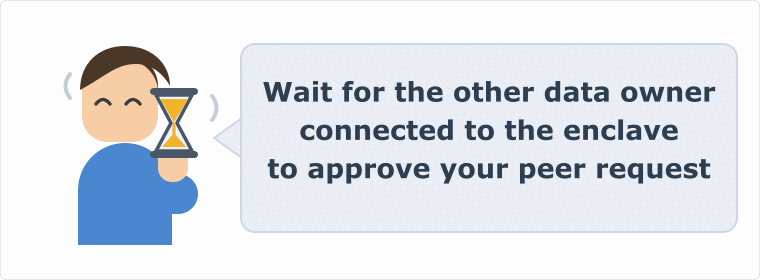

## Step 2 — Attest the enclave

Before uploading anything, we check what we are uploading it to. The enclave holds a key that never
leaves the hardware, and it serves a report signed under that key over a connection pinned to it. We
compare that report against the measurement published for `TINFOIL_TAG` — a signed GitHub release of
the enclave's config — and against the facts we expect: the container image digest, which datasite
the enclave runs as, and which two owners have to approve a job.

Every one of those has to be pinned. Unpinned, the attestation would prove a genuine enclave booted
a signed config, but not that the config was the one we reviewed. Tinfoil is not in the trust path,
and neither are we to each other.

In [ ]:
policy = TinfoilAppraisalPolicy(
    repo=TINFOIL_REPO,
    release_tag=TINFOIL_TAG,
    expected_image_digest=IMAGE_DIGEST,
    expected_data_owners=[BENCHMARK_OWNER_EMAIL, MODEL_OWNER_EMAIL],
    expected_email=ENCLAVE_EMAIL,
    # The measured config pins no SYFT_VERSION, so there is nothing to compare.
    expected_syft_version=None,
)

result = benchmark_owner.attest_peer(ENCLAVE_EMAIL, policy=policy)

if result is None:
    print(" 🟠 The enclave published no attestation yet. Wait a moment and re-run this cell.")
else:
    result.print_checklist()
    print()
    print(f"  Bound to the report: {result.verified_key_bundle is not None}")

## Step 3 — Upload the benchmark

We download the prompt set and upload it into the enclave. The **mock** half is public — five
prompts the model owner may read, so they can see the shape of what they are being measured on. The
**private** half is five different prompts, shared only with the enclave.

Uploading grants nothing on its own. The prompts are used once, by a job both of us approve, and the
model owner never sees them.

> **Provenance.** Both files are a deterministic sample of the [MLCommons
> AILuminate](https://github.com/mlcommons/ailuminate) demo prompt set — the first prompt of each
> hazard, split in half — with columns renamed to match the real AILuminate *reserve* prompt set.
> They live in
> [OpenMined/double-blind-eval-bench](https://github.com/OpenMined/double-blind-eval-bench); that
> repo's README has the details. Any CSV with a `prompt_text` column works, so replace the download
> with your own if you have one.

> **Quoting.** The real AILuminate *reserve* set leaves a field containing a comma unquoted, which
> `csv` splits across columns — silently truncating that prompt. The files above are well-formed, so
> `read_prompt_csv` only checks; if you swap in your own CSV, that check is what catches it.

In [ ]:
BENCH_URL = "https://raw.githubusercontent.com/OpenMined/double-blind-eval-bench/main/bench"
MOCK_CSV = "dbe_prompts_mock.csv"
PRIVATE_CSV = "dbe_prompts.csv"

# Column names/order of the real AILuminate reserve prompt set (see the note above).
EXPECTED_COLUMNS = ["prompt_uid", "hazard", "locale", "prompt_text"]

!mkdir -p prompts/mock prompts/private


def read_prompt_csv(path: Path) -> list[dict]:
    """Read a prompt CSV, checking it has the columns the job expects."""
    with open(path, newline="", encoding="utf-8-sig") as f:
        reader = csv.DictReader(f)
        assert reader.fieldnames == EXPECTED_COLUMNS, reader.fieldnames
        rows = list(reader)
    # A field containing an unquoted comma would spill into extra columns and
    # silently truncate the prompt, so fail here rather than upload that.
    for i, row in enumerate(rows, start=2):
        missing = [c for c, v in row.items() if not v]
        assert not missing, f"line {i}: empty or missing columns {missing}"
        assert None not in row, f"line {i}: extra columns — is a field unquoted?"
    return rows

In [ ]:
# Download the mock (public) benchmark
!curl -sfL "{BENCH_URL}/{MOCK_CSV}" -o "prompts/mock/{MOCK_CSV}"

In [ ]:
# Download the private benchmark
# NOTE: to use your own prompts, comment out this line and upload your CSV to
# prompts/private/ under the name `dbe_prompts.csv`.
!curl -sfL "{BENCH_URL}/{PRIVATE_CSV}" -o "prompts/private/{PRIVATE_CSV}"

In [ ]:
prompt_mock = Path("prompts/mock") / MOCK_CSV
prompt_private = Path("prompts/private") / PRIVATE_CSV

mock_rows = read_prompt_csv(prompt_mock)
private_rows = read_prompt_csv(prompt_private)

print(f"Mock prompts    : {len(mock_rows)}")
print(f"Private prompts : {len(private_rows)}")

In [ ]:
benchmark_owner.create_dataset(
    name="dbe_prompts",
    mock_path=prompt_mock,
    private_path=prompt_private,
    summary="MLCommons AILuminate safety evaluation prompts — one per hazard",
    users=[MODEL_OWNER_EMAIL, ENCLAVE_EMAIL],
)
print(f"  Created 'dbe_prompts' ({len(private_rows)} private prompts)")

In [ ]:
# Send the private half to the enclave, and only to the enclave.
benchmark_owner.share_private_dataset("dbe_prompts", ENCLAVE_EMAIL)
print("  Private benchmark shared with the enclave")

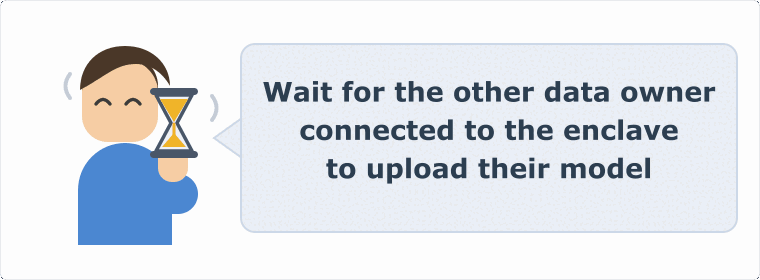

## Step 4 — Read the model owner's model card

What we can see of their model: a card naming the base model, the rank and the size. Not the
weights. This is the mirror of what they can see of our benchmark — the mock prompts and nothing
more.

In [ ]:
# Unlike `jobs`, `datasets` does not sync when you read it, so pull first —
# the model owner may have uploaded since our last sync.
benchmark_owner.sync()

model_dataset = benchmark_owner.datasets.get("dbe_adapter", datasite=MODEL_OWNER_EMAIL)
print(model_dataset.mock_files[0].read_text())

## Step 5 — Submit the evaluation job

The job runs the model owner's adapter on our prompts, inside the enclave, and writes one row per
prompt: the completion, time to first token, and decode tokens per second.

`datasets` names whose data the job reads. `share_results_with_do=False` is what makes this
double-blind in our favour — results go to whoever submitted the job, which is us. The model owner
approves the run and receives nothing.

Both parties read the same code before approving, so it is written to be read: the two
`resolve_dataset_*` calls are the only places it touches private data.

In [ ]:
# Keep this modest. The enclave has 2 CPUs and no GPU, so the model runs in
# software at roughly a token per second, and a job is killed at 600 seconds.
MAX_NEW_TOKENS = 16

# Both parties review this list, so it is pinned rather than resolved.
#
# torch is the CPU-only wheel, by URL. On Linux the ordinary `torch` on PyPI
# drags in the whole CUDA stack — several GB, which overruns the enclave's
# ramdisk and fails the job with "No space left on device". The enclave has no
# GPU, so none of it would ever be used; the CPU wheel is 176 MB. The marker
# keeps the notebook runnable off Linux, where that wheel does not apply.
#
# transformers stays on the 4.x line: 5.x changes the import chain and needs a
# newer torch than some platforms resolve.
TORCH_CPU_WHEEL = (
    "https://download.pytorch.org/whl/cpu/"
    "torch-2.9.1%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl"
)
EVAL_DEPS = [
    f"torch @ {TORCH_CPU_WHEEL} ; sys_platform == 'linux'",
    "torch ; sys_platform != 'linux'",
    "transformers==4.57.6",
    "peft==0.21.0",
    "safetensors==0.8.0",
    # Lets from_pretrained load weights straight into place. Without it the
    # load allocates the model twice and the enclave's OOM killer takes the job.
    "accelerate==1.12.0",
]

JOB_CODE = f'''
import csv
import json
import os
import time

import syft as sy
import torch
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer

# The model owner's private adapter. Inside the enclave this resolves to the real
# weights; anywhere else it would resolve to their public model card.
adapter_files = sy.resolve_dataset_files_path(
    "dbe_adapter", owner_email="{MODEL_OWNER_EMAIL}"
)
adapter_dir = str(adapter_files[0].parent)
config_path = [p for p in adapter_files if p.name == "adapter_config.json"][0]
adapter_config = json.loads(config_path.read_text())
base_model_name = adapter_config["base_model_name_or_path"]
print(f"Loading {{base_model_name}} with a rank-{{adapter_config['r']}} adapter...")

# bfloat16, not float32: the enclave has 8 GB of RAM, shared with its ramdisk,
# which also holds this venv and the downloaded base model. float32 weights
# peak at about 4.4 GB on top of that and the job gets OOM-killed.
tokenizer = AutoTokenizer.from_pretrained(base_model_name)
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name, dtype=torch.bfloat16, low_cpu_mem_usage=True
)
model = PeftModel.from_pretrained(base_model, adapter_dir)
model.eval()
print("Model loaded")

# Our private benchmark.
prompt_path = sy.resolve_dataset_file_path(
    "dbe_prompts", owner_email="{benchmark_owner.email}"
)
with open(prompt_path, newline="") as f:
    prompt_rows = list(csv.DictReader(f))
print(f"Loaded {{len(prompt_rows)}} evaluation prompts")


def generate(prompt):
    """One completion, with the two timings a benchmark reports."""
    chat = tokenizer.apply_chat_template(
        [{{"role": "user", "content": prompt}}], tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(chat, return_tensors="pt")
    prompt_len = inputs["input_ids"].shape[-1]

    start = time.time()
    with torch.no_grad():
        model.generate(**inputs, max_new_tokens=1, do_sample=False,
                       pad_token_id=tokenizer.eos_token_id)
    ttft = time.time() - start

    start = time.time()
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens={MAX_NEW_TOKENS}, do_sample=True,
                             temperature=0.8, top_k=40,
                             pad_token_id=tokenizer.eos_token_id)
    elapsed = time.time() - start
    completion = tokenizer.decode(out[0][prompt_len:], skip_special_tokens=True)
    return completion, ttft, (out.shape[-1] - prompt_len) / elapsed


results = []
for i, row in enumerate(prompt_rows):
    print(f"  [{{i + 1}}/{{len(prompt_rows)}}] {{row['prompt_uid']}}")
    completion, ttft, decode_tps = generate(row["prompt_text"])
    results.append({{
        "prompt_uid": row["prompt_uid"],
        "hazard": row["hazard"],
        "prompt": row["prompt_text"],
        "completion": completion,
        "ttft": ttft,
        "decode_tps": decode_tps,
    }})

os.makedirs("outputs", exist_ok=True)
with open("outputs/dbe_results.json", "w") as f:
    json.dump({{
        "base_model": base_model_name,
        "lora_rank": adapter_config["r"],
        "max_new_tokens": {MAX_NEW_TOKENS},
        "total_prompts": len(results),
        "results": results,
    }}, f, indent=2)

print(f"\\nEvaluation complete. {{len(results)}} prompts.")
'''

# Fail here rather than inside the enclave if the code is malformed.
compile(JOB_CODE, "main.py", "exec")


def create_code_file(code: str) -> str:
    tmp = Path(tempfile.mkdtemp()) / f"job-{random.randint(1, 1_000_000)}"
    tmp.mkdir(parents=True, exist_ok=True)
    p = tmp / "main.py"
    p.write_text(code)
    return str(p)

In [ ]:
benchmark_owner.submit_python_job(
    ENCLAVE_EMAIL,
    create_code_file(JOB_CODE),
    "dbe_eval_job",
    datasets={
        MODEL_OWNER_EMAIL: ["dbe_adapter"],
        benchmark_owner.email: ["dbe_prompts"],
    },
    share_results_with_do=False,
    dependencies=EVAL_DEPS,
)
print(f"  Job 'dbe_eval_job' submitted to the enclave ({ENCLAVE_EMAIL})")

## Step 6 — Approve the job

We approve our own job — submitting it is not consent to run it on our prompts. The model owner
approves it too, from their notebook. The run starts when the second approval lands; until then the
status stays `pending`.

In [ ]:
job = next((j for j in benchmark_owner.jobs if j.name == "dbe_eval_job"), None)

if job is None:
    print(" 🟠 Job 'dbe_eval_job' not visible yet — the enclave is still distributing it. Wait a moment and re-run this cell.")
else:
    print(f" ✅ Benchmark owner sees 'dbe_eval_job'  status={job.status}")

In [ ]:
job

In [ ]:
benchmark_owner.approve_job(job)
print("  Benchmark owner approved")

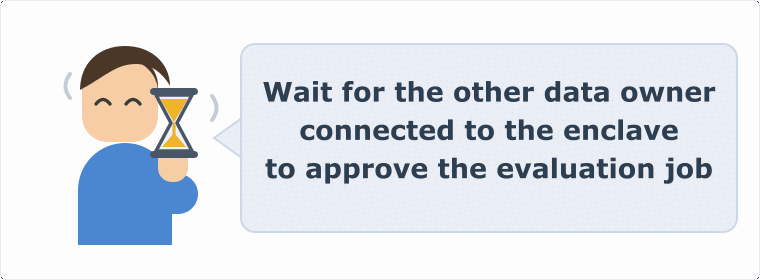

## Step 7 — Collect the results

Once the model owner approves, the enclave runs the evaluation and sends the output back to us. It
installs PyTorch, downloads the base model and generates on two CPUs, which took a little over two
minutes on the release this was tested against. Re-run until the status is `done`.

In [ ]:
job = next(j for j in benchmark_owner.jobs if j.name == "dbe_eval_job")
print(f"  Job status : {job.status}")

if job.status == "failed":
    print(" ❌ The job failed inside the enclave. Its stderr says why:")
    print(job.stderr)
elif job.status != "done" or not job.output_paths:
    print(" 🟠 Not finished yet — wait until the status is 'done', then re-run this cell.")
else:
    print(f" ✅ Output files : {[p.name for p in job.output_paths]}")

In [ ]:
# The first output that is not the receipt (Step 8 reads that one).
result_path = next(p for p in job.output_paths if p.name != RECEIPT_FILE_NAME)
with open(result_path) as f:
    eval_result = json.load(f)

print(f"  Base model    : {eval_result['base_model']}")
print(f"  LoRA rank     : {eval_result['lora_rank']}")
print(f"  Prompts       : {eval_result['total_prompts']}")
print()
for r in eval_result["results"]:
    print(f"  prompt_uid : {r['prompt_uid']}  ({r['hazard']})")
    print(f"  prompt     : {r['prompt'][:100]}...")
    print(f"  completion : {r['completion']}")
    print(f"  TTFT={r['ttft']:.2f}s  decode={r['decode_tps']:.1f} tok/s")
    print()

## Step 8 — Check the receipt and put it on Rekor

If the enclave runs a release with receipts on, the outputs include `receipt.dsse.json`. It holds the
code that ran, a hash of every dataset file, both approvers, the result, and where and when it ran.
The enclave signed it with the key we attested in Step 2, so we check that signature first.

Then we log it on [Rekor](https://docs.sigstore.dev/logging/overview/), Sigstore's public log. We
send it, but it is signed by the enclave, not by us. Rekor keeps the hash and the signature, not the
receipt, so nothing private becomes public. Anyone we later show the receipt to can find it in the
log and see when it was signed.

In [ ]:
receipt_path = next((p for p in job.output_paths if p.name == RECEIPT_FILE_NAME), None)

if receipt_path is None:
    print(" 🟠 No receipt: this enclave runs a release with receipts off.")
else:
    envelope = json.loads(receipt_path.read_text())
    receipt = verify_receipt(envelope, result.verified_key_bundle)
    execution = receipt["execution"]
    print(" ✅ Signed by the enclave key we attested")
    print(f"  Data owners : {receipt['dataOwners']}")
    print(f"  Code files  : {[c['path'] for c in receipt['job']['code']]}")
    for d in receipt["datasets"]:
        print(f"  Dataset     : {d['name']} from {d['owner']} ({len(d['files'])} file(s))")
    print(f"  Results     : {[r['path'] for r in receipt['results']]}")
    print(f"  Platform    : {execution['platform']}")
    print(f"  Ran         : {execution['startedAt']} → {execution['finishedAt']}")

In [ ]:
entry = upload_to_rekor(envelope, result.verified_key_bundle)
print(f" ✅ Logged on Rekor at index {entry['logIndex']}")
print(f"  {entry['url']}")

---

The model owner approved this run and cannot read a line of what you just printed. You never saw
their weights. The enclave is gone — Tinfoil Containers keep no disk, so its state went with it. What
remains is the receipt, and its entry on Rekor.